# Module 12 — Preprocessing Pipeline

**Objective:** Remove leakage-risk columns, select the final feature set,
and construct (but not yet fit) preprocessing pipelines for both models.

In [1]:
import pandas as pd
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

PROJECT_ROOT = Path.cwd().parent
processed_dir = PROJECT_ROOT / "data" / "processed"

individual = pd.read_csv(processed_dir / "individual_features.csv")
sme = pd.read_csv(processed_dir / "sme_features.csv")
print(individual.shape, sme.shape)

(5778, 130) (7805, 27)


C:\Users\pc\AppData\Local\Temp\ipykernel_24400\3116479092.py:11: DtypeWarning: Columns (0: next_pymnt_d) have mixed types. Specify dtype option on import or set low_memory=False.
  individual = pd.read_csv(processed_dir / "individual_features.csv")


## 12.1 Remove Leakage-Risk Columns — Individual Dataset

Any column only populated because the loan already resolved gets
dropped: outcome-dependent payment history, recovery amounts, and the
loan_status text itself (already used to build our target in Module 8).

In [2]:
leakage_cols = [
    "loan_status",                     # source of our target — must not be a feature
    "total_pymnt", "total_pymnt_inv",  # only known after loan resolves
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt",
    "last_credit_pull_d",
    "out_prncp", "out_prncp_inv",      # remaining balance — only exists mid/post-loan
    "next_pymnt_d",
    "policy_code",                     # constant/near-constant, no predictive value
]

# Only drop columns that actually exist, in case any were already removed earlier
leakage_cols_present = [c for c in leakage_cols if c in individual.columns]
individual_model_ready = individual.drop(columns=leakage_cols_present)

print(f"Dropped {len(leakage_cols_present)} leakage-risk columns")
print(f"Shape: {individual.shape} -> {individual_model_ready.shape}")

Dropped 15 leakage-risk columns
Shape: (5778, 130) -> (5778, 115)


## 12.2 Select Final Feature Set — Individual Dataset

Narrowing from ~115 remaining columns to a deliberate, defensible set —
combining raw fields, Module 11's engineered features, and dropping
free-text/ID-like fields (e.g. emp_title, zip_code, title) that need
much heavier NLP-style processing to be useful and are out of scope
here.

In [3]:
numeric_features = [
    "loan_amnt", "int_rate", "installment", "annual_inc", "dti",
    "open_acc", "total_acc", "revol_util", "revol_bal",
    "emp_length_years", "credit_history_years",
    "loan_to_income", "installment_to_income",
    "total_derogatory_events",
]

categorical_features = [
    "grade", "home_ownership", "verification_status",
    "purpose", "utilization_tier",
]

binary_features = ["recent_delinquency_flag", "had_hardship", "had_debt_settlement"]

target = "target_default"

final_individual_cols = numeric_features + categorical_features + binary_features + [target]
individual_model_ready = individual_model_ready[final_individual_cols]

print(f"Final feature set shape: {individual_model_ready.shape}")
individual_model_ready.isna().sum()[individual_model_ready.isna().sum() > 0]

Final feature set shape: (5778, 23)


open_acc              1
total_acc             1
revol_util            3
emp_length_years    325
dtype: int64

## 12.3 Build the Preprocessing Pipeline — Individual Dataset

- Numeric features: impute any remaining missing values with the
  median, then scale (mean 0, std 1) — scaling matters especially for
  our Module 14 baseline, Logistic Regression, which is sensitive to
  feature magnitude.
- Categorical features: one-hot encode (each category becomes its own
  0/1 column) — required since models need numbers, not text labels.
- Binary features: already 0/1, passed through unchanged.

This ColumnTransformer is built now but NOT fit yet — fitting happens
only on the training set, after Module 13's split.

In [4]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

individual_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("bin", "passthrough", binary_features),
])

print("Individual preprocessing pipeline constructed (not yet fit).")

Individual preprocessing pipeline constructed (not yet fit).


## 12.4 SME Dataset — Feature Set and Pipeline

Simpler case: all features are already numeric ratios, no encoding
needed. Only scaling is required.

In [5]:
sme_numeric_features = [
    "Current Ratio", "Long-term Debt / Capital", "Debt/Equity Ratio",
    "Gross Margin", "Operating Margin", "EBIT Margin", "EBITDA Margin",
    "Pre-Tax Profit Margin", "Net Profit Margin", "Asset Turnover",
    "ROE - Return On Equity", "Return On Tangible Equity",
    "ROA - Return On Assets", "ROI - Return On Investment",
    "Operating Cash Flow Per Share", "Free Cash Flow Per Share",
    "margin_spread",
]
sme_binary_features = ["leverage_driven_returns_flag"]
sme_target = "Binary Rating"

sme_model_ready = sme[sme_numeric_features + sme_binary_features + [sme_target]]

sme_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), sme_numeric_features),
    ("bin", "passthrough", sme_binary_features),
])

print(f"SME model-ready shape: {sme_model_ready.shape}")
print("SME preprocessing pipeline constructed (not yet fit).")

SME model-ready shape: (7805, 19)
SME preprocessing pipeline constructed (not yet fit).


## 12.5 Save Model-Ready Feature Sets

In [6]:
individual_model_ready.to_csv(processed_dir / "individual_model_ready.csv", index=False)
sme_model_ready.to_csv(processed_dir / "sme_model_ready.csv", index=False)

print(f"individual_model_ready saved: {individual_model_ready.shape}")
print(f"sme_model_ready saved: {sme_model_ready.shape}")

individual_model_ready saved: (5778, 23)
sme_model_ready saved: (7805, 19)


# Module 13 — Train / Test Split

**Objective:** Split both datasets into training and test sets using
stratified sampling, then fit each preprocessing pipeline on training
data only.

In [7]:
from sklearn.model_selection import train_test_split

individual = pd.read_csv(processed_dir / "individual_model_ready.csv")
sme = pd.read_csv(processed_dir / "sme_model_ready.csv")

## 13.1 Individual Dataset Split

80/20 split, stratified on target_default to preserve the 80/20
default rate in both sets.

In [8]:
X_ind = individual.drop(columns=["target_default"])
y_ind = individual["target_default"]

X_ind_train, X_ind_test, y_ind_train, y_ind_test = train_test_split(
    X_ind, y_ind,
    test_size=0.2,
    stratify=y_ind,
    random_state=42
)

print(f"Train shape: {X_ind_train.shape}, Test shape: {X_ind_test.shape}")
print(f"\nTrain default rate: {y_ind_train.mean()*100:.2f}%")
print(f"Test default rate: {y_ind_test.mean()*100:.2f}%")

Train shape: (4622, 22), Test shape: (1156, 22)

Train default rate: 20.08%
Test default rate: 20.07%


## 13.2 SME Dataset Split

Same approach, stratified on Binary Rating.

In [9]:
X_sme = sme.drop(columns=["Binary Rating"])
y_sme = sme["Binary Rating"]

X_sme_train, X_sme_test, y_sme_train, y_sme_test = train_test_split(
    X_sme, y_sme,
    test_size=0.2,
    stratify=y_sme,
    random_state=42
)

print(f"Train shape: {X_sme_train.shape}, Test shape: {X_sme_test.shape}")
print(f"\nTrain investment-grade rate: {y_sme_train.mean()*100:.2f}%")
print(f"Test investment-grade rate: {y_sme_test.mean()*100:.2f}%")

Train shape: (6244, 18), Test shape: (1561, 18)

Train investment-grade rate: 65.33%
Test investment-grade rate: 65.34%


## 13.3 Fit Preprocessing Pipelines — Training Data Only

fit_transform on training data (learns + applies).
transform only on test data (applies what was already learned — no
re-learning, no peeking).

In [10]:
X_ind_train_processed = individual_preprocessor.fit_transform(X_ind_train)
X_ind_test_processed = individual_preprocessor.transform(X_ind_test)

print(f"Individual train processed shape: {X_ind_train_processed.shape}")
print(f"Individual test processed shape: {X_ind_test_processed.shape}")

Individual train processed shape: (4622, 51)
Individual test processed shape: (1156, 51)


In [11]:
X_sme_train_processed = sme_preprocessor.fit_transform(X_sme_train)
X_sme_test_processed = sme_preprocessor.transform(X_sme_test)

print(f"SME train processed shape: {X_sme_train_processed.shape}")
print(f"SME test processed shape: {X_sme_test_processed.shape}")

SME train processed shape: (6244, 18)
SME test processed shape: (1561, 18)


## 13.4 Save Split Datasets

Saving both raw splits and processed arrays — raw splits let us
re-inspect readable feature values later; processed arrays are what
actually feed into Module 14's model.

In [12]:
import joblib

split_dir = PROJECT_ROOT / "data" / "processed" / "splits"
split_dir.mkdir(exist_ok=True)

joblib.dump(X_ind_train, split_dir / "X_ind_train.pkl")
joblib.dump(X_ind_test, split_dir / "X_ind_test.pkl")
joblib.dump(y_ind_train, split_dir / "y_ind_train.pkl")
joblib.dump(y_ind_test, split_dir / "y_ind_test.pkl")
joblib.dump(X_ind_train_processed, split_dir / "X_ind_train_processed.pkl")
joblib.dump(X_ind_test_processed, split_dir / "X_ind_test_processed.pkl")

joblib.dump(X_sme_train, split_dir / "X_sme_train.pkl")
joblib.dump(X_sme_test, split_dir / "X_sme_test.pkl")
joblib.dump(y_sme_train, split_dir / "y_sme_train.pkl")
joblib.dump(y_sme_test, split_dir / "y_sme_test.pkl")
joblib.dump(X_sme_train_processed, split_dir / "X_sme_train_processed.pkl")
joblib.dump(X_sme_test_processed, split_dir / "X_sme_test_processed.pkl")

print("All train/test splits saved to data/processed/splits/")

All train/test splits saved to data/processed/splits/


# Module 14 — Baseline Model: Logistic Regression

**Objective:** Train a Logistic Regression model on both datasets and
establish baseline performance to compare all future models against.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# class_weight='balanced' compensates for our 80/20 imbalance (Module 8) —
# without it, the model could get 80% accuracy by just always predicting "no default"
log_reg_individual = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg_individual.fit(X_ind_train_processed, y_ind_train)

y_ind_pred = log_reg_individual.predict(X_ind_test_processed)
y_ind_proba = log_reg_individual.predict_proba(X_ind_test_processed)[:, 1]

print("Individual Model — Logistic Regression Baseline")
print(classification_report(y_ind_test, y_ind_pred))
print(f"ROC-AUC: {roc_auc_score(y_ind_test, y_ind_proba):.4f}")

Individual Model — Logistic Regression Baseline
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       924
           1       0.35      0.64      0.45       232

    accuracy                           0.69      1156
   macro avg       0.62      0.67      0.62      1156
weighted avg       0.78      0.69      0.71      1156

ROC-AUC: 0.7397


In [14]:
log_reg_sme = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg_sme.fit(X_sme_train_processed, y_sme_train)

y_sme_pred = log_reg_sme.predict(X_sme_test_processed)
y_sme_proba = log_reg_sme.predict_proba(X_sme_test_processed)[:, 1]

print("SME Model — Logistic Regression Baseline")
print(classification_report(y_sme_test, y_sme_pred))
print(f"ROC-AUC: {roc_auc_score(y_sme_test, y_sme_proba):.4f}")

SME Model — Logistic Regression Baseline
              precision    recall  f1-score   support

           0       0.62      0.73      0.67       541
           1       0.84      0.76      0.80      1020

    accuracy                           0.75      1561
   macro avg       0.73      0.75      0.73      1561
weighted avg       0.76      0.75      0.75      1561

ROC-AUC: 0.8142


# Module 15 — Advanced Models: Random Forest & XGBoost

**Objective:** Train Random Forest and XGBoost on both datasets, and
compare all four models (2 datasets x 2 algorithms) against the
Logistic Regression baselines from Module 14.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

results = {}  # we'll collect every model's ROC-AUC here for a clean comparison later

def evaluate(name, y_true, y_proba, y_pred):
    auc = roc_auc_score(y_true, y_proba)
    results[name] = auc
    print(f"{name}")
    print(classification_report(y_true, y_pred))
    print(f"ROC-AUC: {auc:.4f}\n")

# Record the Module 14 baselines too, so the comparison table is complete
results["Individual - Logistic Regression"] = roc_auc_score(y_ind_test, y_ind_proba)
results["SME - Logistic Regression"] = roc_auc_score(y_sme_test, y_sme_proba)

## 15.1 Random Forest — Individual Model

In [16]:
rf_individual = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf_individual.fit(X_ind_train_processed, y_ind_train)

y_pred = rf_individual.predict(X_ind_test_processed)
y_proba = rf_individual.predict_proba(X_ind_test_processed)[:, 1]
evaluate("Individual - Random Forest", y_ind_test, y_proba, y_pred)

Individual - Random Forest
              precision    recall  f1-score   support

           0       0.88      0.74      0.80       924
           1       0.37      0.59      0.45       232

    accuracy                           0.71      1156
   macro avg       0.62      0.67      0.63      1156
weighted avg       0.78      0.71      0.73      1156

ROC-AUC: 0.7380



## 15.2 XGBoost — Individual Model

scale_pos_weight is XGBoost's equivalent of class_weight='balanced' —
it upweights the minority class (defaults) during training.

In [17]:
scale_pos_weight = (y_ind_train == 0).sum() / (y_ind_train == 1).sum()

xgb_individual = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", random_state=42
)
xgb_individual.fit(X_ind_train_processed, y_ind_train)

y_pred = xgb_individual.predict(X_ind_test_processed)
y_proba = xgb_individual.predict_proba(X_ind_test_processed)[:, 1]
evaluate("Individual - XGBoost", y_ind_test, y_proba, y_pred)

Individual - XGBoost
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       924
           1       0.38      0.48      0.43       232

    accuracy                           0.74      1156
   macro avg       0.62      0.64      0.63      1156
weighted avg       0.76      0.74      0.75      1156

ROC-AUC: 0.7172



## 15.3 Random Forest — SME Model

In [18]:
rf_sme = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf_sme.fit(X_sme_train_processed, y_sme_train)

y_pred = rf_sme.predict(X_sme_test_processed)
y_proba = rf_sme.predict_proba(X_sme_test_processed)[:, 1]
evaluate("SME - Random Forest", y_sme_test, y_proba, y_pred)

SME - Random Forest
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       541
           1       0.90      0.91      0.90      1020

    accuracy                           0.87      1561
   macro avg       0.86      0.86      0.86      1561
weighted avg       0.87      0.87      0.87      1561

ROC-AUC: 0.9389



## 15.4 XGBoost — SME Model

In [19]:
scale_pos_weight_sme = (y_sme_train == 0).sum() / (y_sme_train == 1).sum()

xgb_sme = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_sme,
    eval_metric="logloss", random_state=42
)
xgb_sme.fit(X_sme_train_processed, y_sme_train)

y_pred = xgb_sme.predict(X_sme_test_processed)
y_proba = xgb_sme.predict_proba(X_sme_test_processed)[:, 1]
evaluate("SME - XGBoost", y_sme_test, y_proba, y_pred)

SME - XGBoost
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       541
           1       0.93      0.91      0.92      1020

    accuracy                           0.90      1561
   macro avg       0.89      0.89      0.89      1561
weighted avg       0.90      0.90      0.90      1561

ROC-AUC: 0.9547



## 15.5 Model Comparison Table

In [20]:
comparison = pd.DataFrame(results.items(), columns=["Model", "ROC-AUC"]).sort_values("ROC-AUC", ascending=False)
comparison

,Model,ROC-AUC
5,SME - XGBoost,0.954659
4,SME - Random Forest,0.938917
1,SME - Logistic Regression,0.814215
0,Individual - Logistic Regression,0.739686
2,Individual - Random Forest,0.737997
3,Individual - XGBoost,0.717234


In [21]:
import joblib

models_dir = PROJECT_ROOT / "models"
joblib.dump(rf_individual, models_dir / "rf_individual.pkl")
joblib.dump(xgb_individual, models_dir / "xgb_individual.pkl")
joblib.dump(rf_sme, models_dir / "rf_sme.pkl")
joblib.dump(xgb_sme, models_dir / "xgb_sme.pkl")
print("All four advanced models saved to models/")

All four advanced models saved to models/


## 15.6 Sanity Check — Train vs Test AUC (Overfitting Diagnostic)

A model that scores much higher on training data than test data is
memorizing, not learning. Checking this before trusting the SME
XGBoost result.

In [22]:
train_auc_sme_xgb = roc_auc_score(y_sme_train, xgb_sme.predict_proba(X_sme_train_processed)[:, 1])
test_auc_sme_xgb = roc_auc_score(y_sme_test, xgb_sme.predict_proba(X_sme_test_processed)[:, 1])
print(f"SME XGBoost — Train AUC: {train_auc_sme_xgb:.4f} | Test AUC: {test_auc_sme_xgb:.4f}")

train_auc_ind_xgb = roc_auc_score(y_ind_train, xgb_individual.predict_proba(X_ind_train_processed)[:, 1])
test_auc_ind_xgb = roc_auc_score(y_ind_test, xgb_individual.predict_proba(X_ind_test_processed)[:, 1])
print(f"Individual XGBoost — Train AUC: {train_auc_ind_xgb:.4f} | Test AUC: {test_auc_ind_xgb:.4f}")

SME XGBoost — Train AUC: 0.9867 | Test AUC: 0.9547
Individual XGBoost — Train AUC: 0.9623 | Test AUC: 0.7172


## 15.7 Hyperparameter Tuning — Individual XGBoost

Random Forest and XGBoost underperformed the Logistic Regression
baseline with default settings — likely overfitting on a relatively
small, high-dimensional dataset. Tuning key parameters (depth, learning
rate, regularization) to see if that gap closes.

In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_lambda": [1, 5, 10],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42),
    param_distributions=param_dist,
    n_iter=30, scoring="roc_auc", cv=5, random_state=42, n_jobs=-1
)
xgb_search.fit(X_ind_train_processed, y_ind_train)

print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

xgb_individual_tuned = xgb_search.best_estimator_
y_proba = xgb_individual_tuned.predict_proba(X_ind_test_processed)[:, 1]
y_pred = xgb_individual_tuned.predict(X_ind_test_processed)
evaluate("Individual - XGBoost (Tuned)", y_ind_test, y_proba, y_pred)

Best params: {'subsample': 0.7, 'reg_lambda': 1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.7539
Individual - XGBoost (Tuned)
              precision    recall  f1-score   support

           0       0.88      0.72      0.79       924
           1       0.36      0.62      0.45       232

    accuracy                           0.70      1156
   macro avg       0.62      0.67      0.62      1156
weighted avg       0.78      0.70      0.72      1156

ROC-AUC: 0.7377



In [27]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_distributions={
        "max_depth": [3, 4, 5, 6, 8],
        "n_estimators": [100, 200, 300],
        "min_samples_leaf": [5, 10, 20, 30],
        "max_features": ["sqrt", "log2", 0.5],
    },
    n_iter=20, scoring="roc_auc", cv=5, random_state=42, n_jobs=-1
)
rf_search.fit(X_ind_train_processed, y_ind_train)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

rf_individual_tuned = rf_search.best_estimator_
y_proba = rf_individual_tuned.predict_proba(X_ind_test_processed)[:, 1]
y_pred = rf_individual_tuned.predict(X_ind_test_processed)
evaluate("Individual - Random Forest (Tuned)", y_ind_test, y_proba, y_pred)

Best params: {'n_estimators': 300, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 6}
Best CV ROC-AUC: 0.7497
Individual - Random Forest (Tuned)
              precision    recall  f1-score   support

           0       0.89      0.71      0.79       924
           1       0.36      0.66      0.47       232

    accuracy                           0.70      1156
   macro avg       0.63      0.68      0.63      1156
weighted avg       0.79      0.70      0.72      1156

ROC-AUC: 0.7387



# Module 16 — Model Evaluation

**Objective:** Build confusion matrices and ROC curves for both final
models, and interpret results in lending-decision terms.

In [28]:
figures_dir = PROJECT_ROOT / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

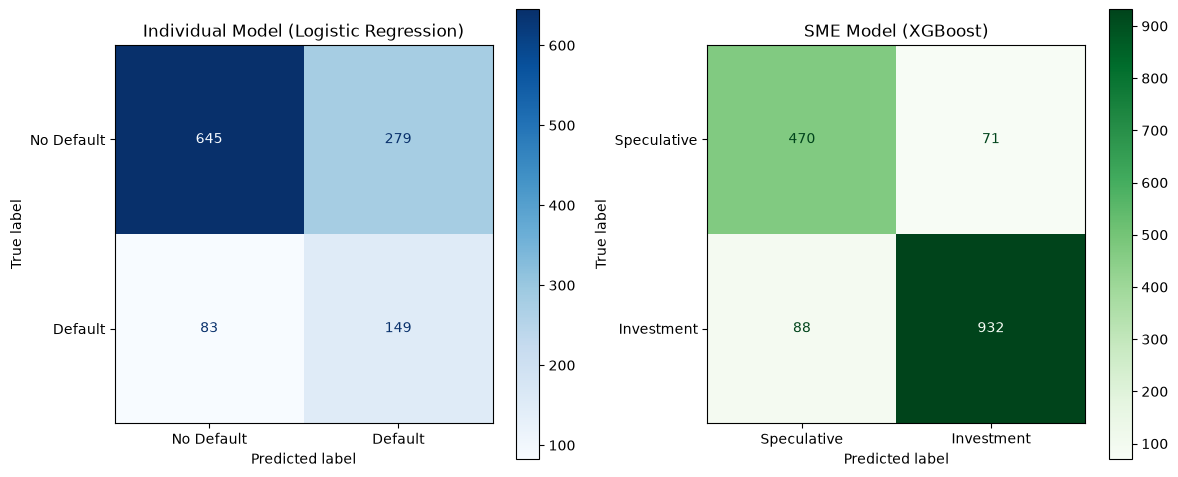

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_ind = confusion_matrix(y_ind_test, log_reg_individual.predict(X_ind_test_processed))
ConfusionMatrixDisplay(cm_ind, display_labels=["No Default", "Default"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Individual Model (Logistic Regression)")

cm_sme = confusion_matrix(y_sme_test, xgb_sme.predict(X_sme_test_processed))
ConfusionMatrixDisplay(cm_sme, display_labels=["Speculative", "Investment"]).plot(ax=axes[1], cmap="Greens")
axes[1].set_title("SME Model (XGBoost)")

plt.tight_layout()
plt.show()

## 16.1 ROC Curves

The curve shows the trade-off between catching true defaulters (True
Positive Rate) and wrongly flagging good borrowers (False Positive
Rate) as the decision threshold moves. The diagonal line represents
random guessing — the further above it, the better the model.

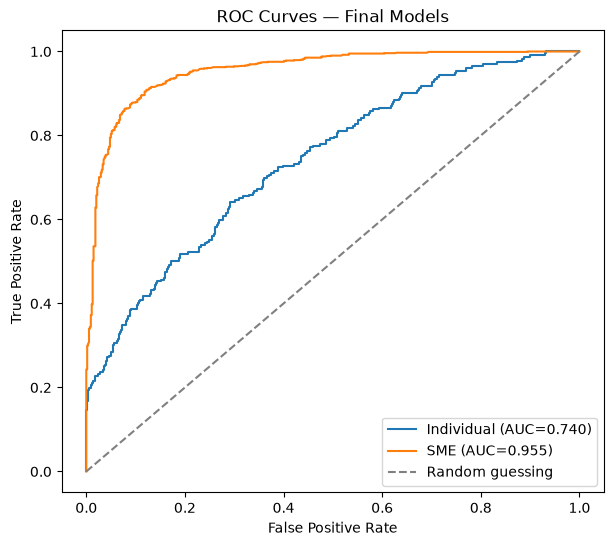

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))

fpr_ind, tpr_ind, _ = roc_curve(y_ind_test, y_ind_proba)
ax.plot(fpr_ind, tpr_ind, label=f"Individual (AUC={roc_auc_score(y_ind_test, y_ind_proba):.3f})")

fpr_sme, tpr_sme, _ = roc_curve(y_sme_test, xgb_sme.predict_proba(X_sme_test_processed)[:, 1])
ax.plot(fpr_sme, tpr_sme, label=f"SME (AUC={roc_auc_score(y_sme_test, xgb_sme.predict_proba(X_sme_test_processed)[:, 1]):.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Final Models")
ax.legend()
plt.show()

## 16.2 Threshold Impact — Precision/Recall Trade-off in Practice

Our classification_report uses the default 0.5 threshold. But a bank
can move this threshold based on risk appetite. Showing what happens
at a stricter threshold (0.3) for the individual model — catches more
defaulters, at the cost of more false alarms.

In [31]:
for threshold in [0.3, 0.5, 0.7]:
    y_pred_thresh = (y_ind_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_ind_test, y_pred_thresh).ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"Threshold {threshold}: Recall={recall:.2f}, Precision={precision:.2f}, "
          f"Defaults caught={tp}/{tp+fn}, False alarms={fp}")

Threshold 0.3: Recall=0.90, Precision=0.26, Defaults caught=208/232, False alarms=591
Threshold 0.5: Recall=0.64, Precision=0.35, Defaults caught=149/232, False alarms=279
Threshold 0.7: Recall=0.30, Precision=0.57, Defaults caught=70/232, False alarms=52


# Module 17 — Explainable AI (SHAP)

**Objective:** Generate global feature importance and individual
prediction explanations for both final models.

In [32]:
import shap

figures_dir = PROJECT_ROOT / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Get readable feature names out of the ColumnTransformer for plotting
individual_feature_names = individual_preprocessor.get_feature_names_out()
sme_feature_names = sme_preprocessor.get_feature_names_out()

## 17.1 Global Explanation — Individual Model (Logistic Regression)

TreeExplainer is for tree models only, so a linear model uses
LinearExplainer instead — same idea, different math under the hood.

Background dataset has 4622 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4622 when initializing the masker.


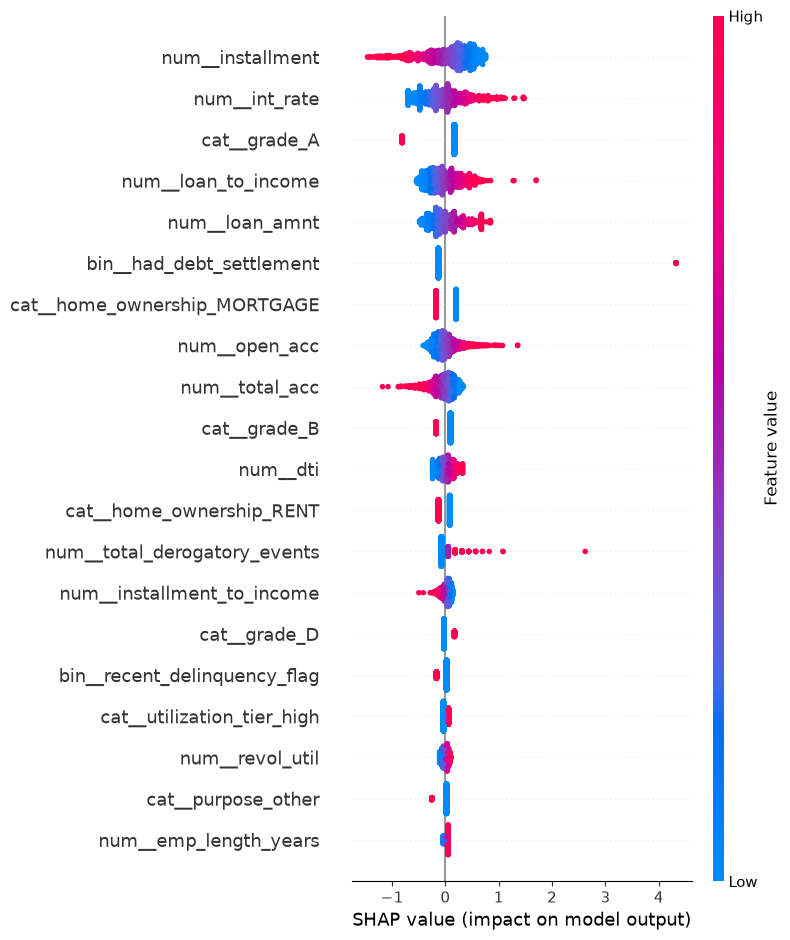

In [33]:
explainer_ind = shap.LinearExplainer(log_reg_individual, X_ind_train_processed)
shap_values_ind = explainer_ind(X_ind_test_processed)
shap_values_ind.feature_names = list(individual_feature_names)

shap.summary_plot(shap_values_ind, X_ind_test_processed, feature_names=list(individual_feature_names), show=False)
plt.tight_layout()
plt.savefig(figures_dir / "shap_summary_individual.png", dpi=150, bbox_inches="tight")
plt.show()

## 17.2 Global Explanation — SME Model (XGBoost)

TreeExplainer is optimized specifically for tree-based models like
XGBoost — much faster than the general-purpose explainer.

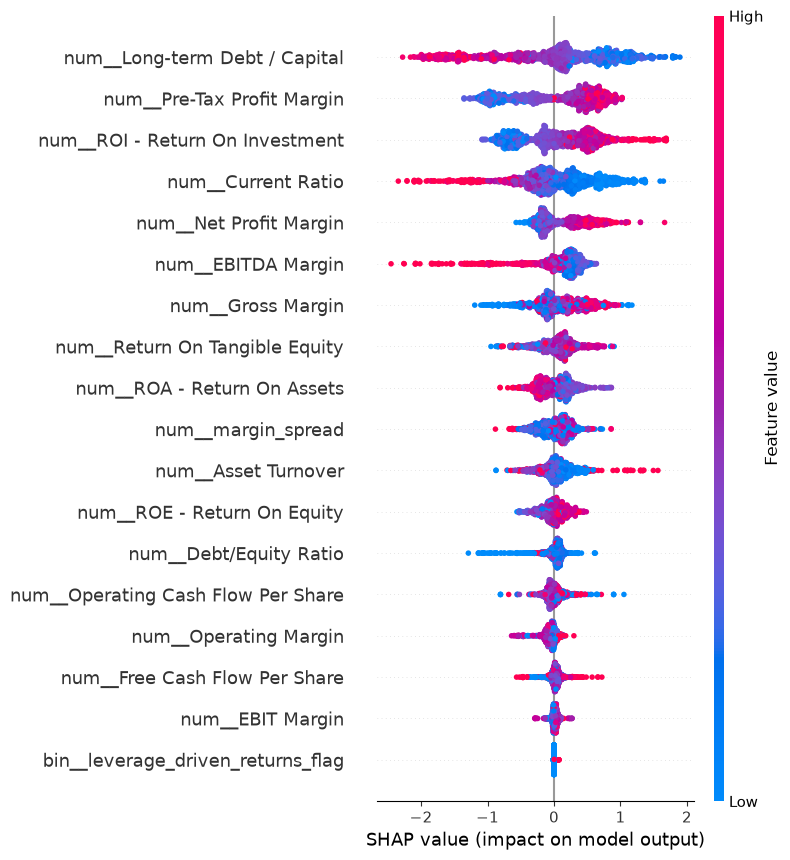

In [34]:
explainer_sme = shap.TreeExplainer(xgb_sme)
shap_values_sme = explainer_sme(X_sme_test_processed)
shap_values_sme.feature_names = list(sme_feature_names)

shap.summary_plot(shap_values_sme, X_sme_test_processed, feature_names=list(sme_feature_names), show=False)
plt.tight_layout()
plt.savefig(figures_dir / "shap_summary_sme.png", dpi=150, bbox_inches="tight")
plt.show()

## 17.3 Local Explanation — One Individual Borrower

Picking one borrower from the test set who actually defaulted, and
showing exactly which features drove that specific prediction.

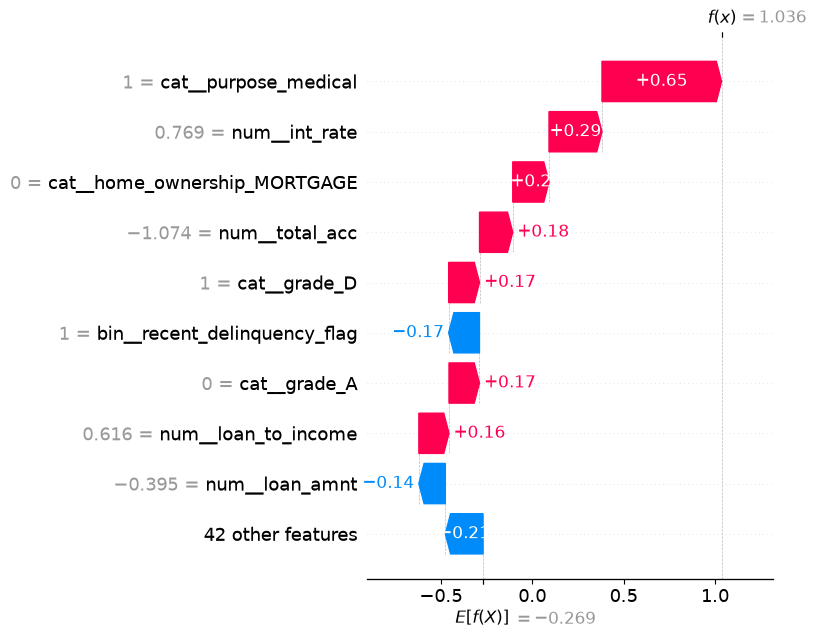

In [35]:
# Find the index of a borrower who defaulted, for a meaningful example
defaulter_idx = y_ind_test.reset_index(drop=True)[y_ind_test.reset_index(drop=True) == 1].index[0]

shap.plots.waterfall(shap_values_ind[defaulter_idx], show=False)
plt.tight_layout()
plt.savefig(figures_dir / "shap_waterfall_individual_example.png", dpi=150, bbox_inches="tight")
plt.show()

## 17.4 Local Explanation — One SME Borrower

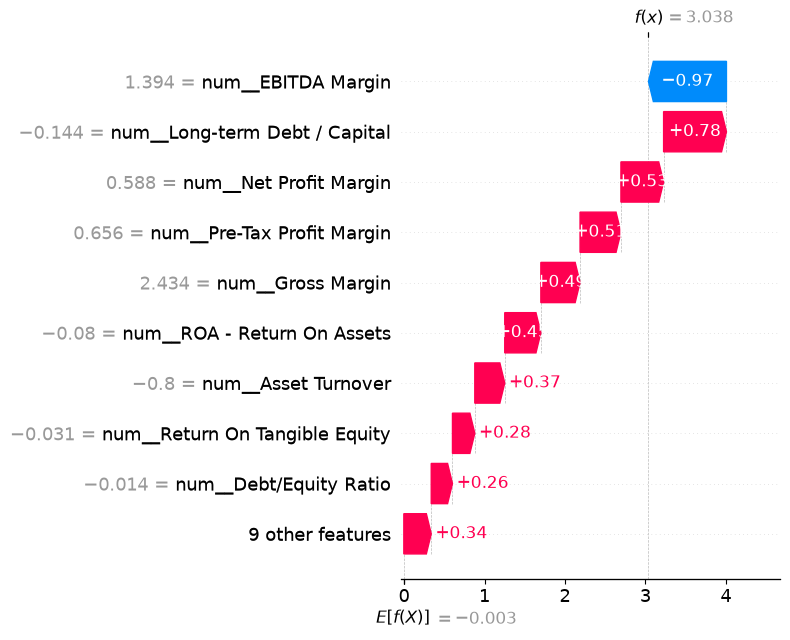

In [36]:
speculative_idx = y_sme_test.reset_index(drop=True)[y_sme_test.reset_index(drop=True) == 0].index[0]

shap.plots.waterfall(shap_values_sme[speculative_idx], show=False)
plt.tight_layout()
plt.savefig(figures_dir / "shap_waterfall_sme_example.png", dpi=150, bbox_inches="tight")
plt.show()

# Module 18 — Risk Grade Framework

**Objective:** Convert model-predicted probabilities into a 10-tier
letter grade system (AAA best -> D worst), calibrated to each
model's own population.

In [37]:
grade_labels = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC", "CC", "C", "D"]

def build_grade_thresholds(probabilities, labels=grade_labels):
    """
    Splits a population's predicted risk probabilities into equal-sized
    deciles, best (lowest risk) to worst (highest risk), and returns
    the bin edges alongside the labels.
    """
    quantiles = np.linspace(0, 1, len(labels) + 1)
    edges = np.quantile(probabilities, quantiles)
    edges[0], edges[-1] = 0, 1  # ensure full 0-1 coverage for future unseen predictions
    return edges

def assign_grade(probability, edges, labels=grade_labels):
    for i in range(len(labels)):
        if edges[i] <= probability <= edges[i + 1]:
            return labels[i]
    return labels[-1]

In [38]:
import numpy as np

# Individual model: y_ind_proba is P(default) — already our risk score
individual_edges = build_grade_thresholds(y_ind_proba)
individual_grades = [assign_grade(p, individual_edges) for p in y_ind_proba]

grade_check = pd.DataFrame({"risk_grade": individual_grades, "actual_default": y_ind_test.values})
grade_check["risk_grade"] = pd.Categorical(grade_check["risk_grade"], categories=grade_labels, ordered=True)

default_by_grade = grade_check.groupby("risk_grade", observed=True)["actual_default"].mean() * 100
print(default_by_grade)

risk_grade
AAA     4.310345
AA      5.172414
A      10.434783
BBB    15.517241
BB     14.782609
B      18.103448
CCC    24.347826
CC     18.965517
C      32.173913
D      56.896552
Name: actual_default, dtype: float64


## 18.1 Validate: Does Default Rate Rise Monotonically Across Grades?

Same sanity check as Module 9's LendingClub-grade validation — if our
own risk grades don't show a rising default rate from AAA to D, the
grading system isn't working, regardless of how good the underlying
model's AUC looked.

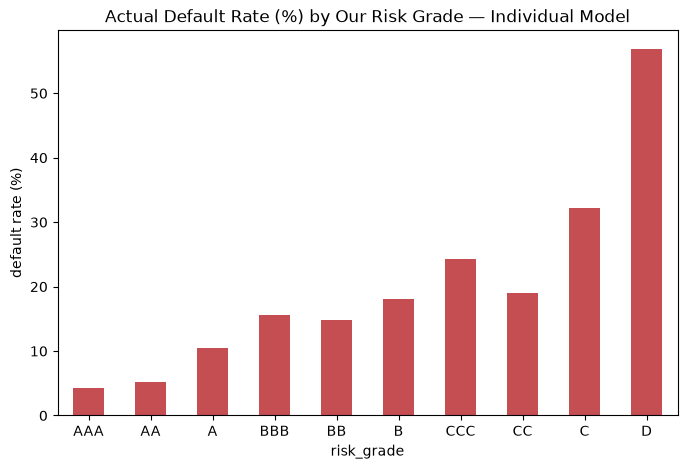

In [39]:
default_by_grade.plot(kind="bar", color="#C44E52", figsize=(8, 5))
plt.title("Actual Default Rate (%) by Our Risk Grade — Individual Model")
plt.ylabel("default rate (%)")
plt.xticks(rotation=0)
plt.savefig(figures_dir / "risk_grade_validation_individual.png", dpi=150, bbox_inches="tight")
plt.show()

## 18.2 SME Risk Grades — with a Real-World Comparison

Unique advantage here: the SME dataset has ACTUAL agency ratings
(the original 'Rating' column) that we set aside back in Module 12.
We can compare our model-derived grades against the real agency
grades as a genuine external validity check — something the
individual model can't do, since LendingClub's own grade already got
absorbed into our feature set.

In [40]:
# Our SME model predicts P(Investment Grade). Risk = P(Speculative) = 1 - that.
sme_proba = xgb_sme.predict_proba(X_sme_test_processed)[:, 1]
sme_risk_proba = 1 - sme_proba

sme_edges = build_grade_thresholds(sme_risk_proba)
sme_our_grades = [assign_grade(p, sme_edges) for p in sme_risk_proba]

# Pull back the real agency ratings for the same test rows
sme_actual_ratings = sme.loc[X_sme_test.index, "Rating"] if "Rating" in sme.columns else None
print("Note: 'Rating' column availability check —", "found" if sme_actual_ratings is not None else "not in this dataframe, will reload")

Note: 'Rating' column availability check — not in this dataframe, will reload


In [41]:
# Reload original SME data to get the real letter ratings back (dropped in Module 12)
sme_original = pd.read_csv(processed_dir / "sme_features.csv")
sme_actual_ratings = sme_original.loc[X_sme_test.index, "Rating"].values

sme_comparison = pd.DataFrame({
    "our_grade": sme_our_grades,
    "actual_agency_rating": sme_actual_ratings,
    "actual_binary_rating": y_sme_test.values
})
sme_comparison["our_grade"] = pd.Categorical(sme_comparison["our_grade"], categories=grade_labels, ordered=True)

# Does our grade correlate with the REAL agency rating being investment-grade?
investment_rate_by_our_grade = sme_comparison.groupby("our_grade", observed=True)["actual_binary_rating"].mean() * 100
print(investment_rate_by_our_grade)

our_grade
AAA    100.000000
AA      98.701299
A       96.794872
BBB     98.101266
BB      93.548387
B       81.935484
CCC     54.487179
CC      19.745223
C        9.032258
D        0.641026
Name: actual_binary_rating, dtype: float64


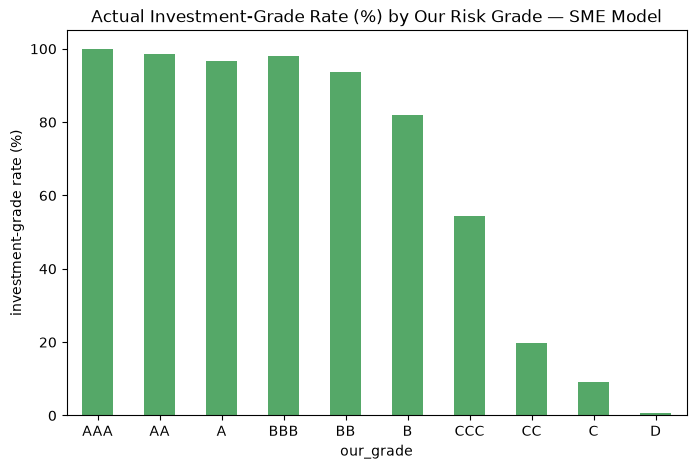

In [42]:
investment_rate_by_our_grade.plot(kind="bar", color="#55A868", figsize=(8, 5))
plt.title("Actual Investment-Grade Rate (%) by Our Risk Grade — SME Model")
plt.ylabel("investment-grade rate (%)")
plt.xticks(rotation=0)
plt.savefig(figures_dir / "risk_grade_validation_sme.png", dpi=150, bbox_inches="tight")
plt.show()

## 18.3 Save Grade Thresholds and Assignment Function

These thresholds need to travel with the model into Module 20
(serialization) and Module 21 (prediction engine) — every future
prediction needs to go through this exact same scale.

In [43]:
grade_config = {
    "individual_edges": individual_edges.tolist(),
    "sme_edges": sme_edges.tolist(),
    "labels": grade_labels,
}

import json
with open(models_dir / "risk_grade_thresholds.json", "w") as f:
    json.dump(grade_config, f, indent=2)

print("Saved risk grade thresholds to models/risk_grade_thresholds.json")

Saved risk grade thresholds to models/risk_grade_thresholds.json


# Module 19 — Model Comparison: Individual vs SME

## Performance

| Aspect | Individual Model | SME Model |
|---|---|---|
| Final algorithm | Logistic Regression | XGBoost (tuned) |
| Test ROC-AUC | 0.740 | 0.955 |
| Train/test AUC gap | Small (well-calibrated) | Small (0.987 vs 0.955 — healthy) |
| Risk grade validation | Mostly monotonic, 2 minor inversions | Near-perfect monotonic, validated against real agency ratings |

The SME model is unambiguously the stronger performer. This isn't a
modeling failure on the individual side — Module 15 showed three
different algorithms (Logistic Regression, Random Forest, XGBoost, all
tuned) converge to the same ~0.74 ceiling, meaning the gap is coming
from the DATA, not the ALGORITHM CHOICE.

## Why the Gap Exists (the actual finding, not just the number)

Financial ratios (SME) have a direct, near-mechanical relationship to
creditworthiness — a company with strong margins and manageable
leverage is measurably healthier, and that relationship is stable and
well-understood by decades of corporate finance theory. Individual
default behavior depends on human financial decisions, life events
(job loss, medical bills — recall our hardship flag from Module 8),
and circumstances that a static loan-application snapshot simply
cannot fully capture. This is a known, real distinction in the credit
risk industry, not an artifact of this specific project — consumer
credit models generally underperform corporate/commercial credit
models on pure statistical fit, for exactly this reason.

## Interpretability

The individual model's choice of Logistic Regression over an
equally-performing tree ensemble (Module 15's decision) means every
prediction has a literal linear equation behind it — the most
interpretable model type available. The SME model uses XGBoost, which
required SHAP (Module 17) to become interpretable — a necessary extra
step, but one that paid off, since SHAP's Long-term Debt/Capital
finding matched textbook leverage theory almost exactly.

## Business Usefulness

Individual model: best suited for high-volume, fast, explainable
decisioning — exactly what consumer lending needs, where thousands of
small decisions must be made quickly and defensibly (recall Module 16:
adverse action requirements make interpretability a legal necessity,
not a preference, in this domain).

SME model: best suited for lower-volume, higher-stakes decisions where
more computational complexity is affordable, and where the external
validation against real agency ratings (Module 18) gives real
confidence for high-dollar lending decisions.

## Limitations

Individual model: trained on a 10,000-row SAMPLE, not the full
1.1GB dataset — the final full-scale run (on your own machine,
Module 4's plan) may shift these numbers, hopefully upward with more
training data. Missing key delinquency-history depth (Module 11 found
weaker-than-expected delinquency signal, possibly due to sample size).

SME model: missing Quick Ratio and Interest Coverage Ratio (Module 10's
documented data limitation) — a real commercial underwriter would want
both. Smaller dataset overall (7,805 rows) means fewer examples in the
most extreme rating categories (very few AAA or D-rated companies),
which could limit reliability at the tails.

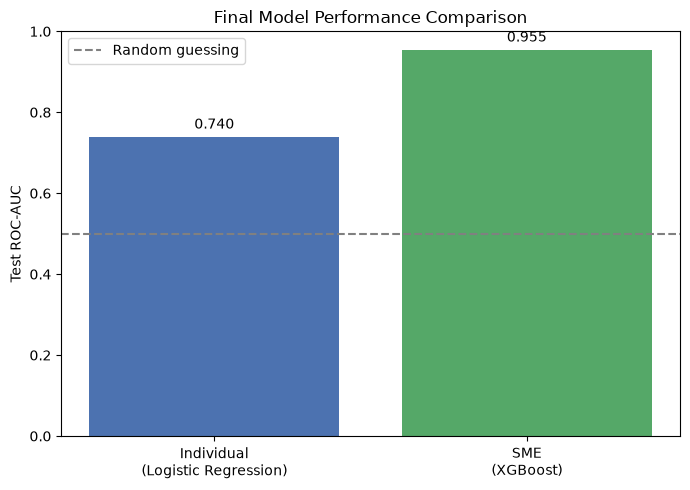

In [44]:
comparison_metrics = pd.DataFrame({
    "Model": ["Individual\n(Logistic Regression)", "SME\n(XGBoost)"],
    "Test ROC-AUC": [0.7397, 0.9547],
})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(comparison_metrics["Model"], comparison_metrics["Test ROC-AUC"], color=["#4C72B0", "#55A868"])
ax.set_ylim(0, 1)
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Final Model Performance Comparison")
ax.axhline(0.5, linestyle="--", color="gray", label="Random guessing")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.3f}", ha="center")
ax.legend()
plt.tight_layout()
plt.savefig(figures_dir / "final_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Module 20 — Model Serialization

**Objective:** Package each final model with its preprocessor, feature
list, and risk grade thresholds into a versioned, documented artifact —
then verify it reloads and predicts identically.

In [45]:
import joblib
import json
from datetime import datetime

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)

VERSION = "v1.0.0"

## 20.1 Package the Individual Model

Everything needed to score a new individual borrower, bundled as one
dictionary, saved as one file. This is the actual deployable unit —
not just the model.

In [46]:
individual_package = {
    "model": log_reg_individual,
    "preprocessor": individual_preprocessor,
    "feature_names_raw": numeric_features + categorical_features + binary_features,
    "feature_names_processed": list(individual_feature_names),
    "risk_grade_edges": individual_edges.tolist(),
    "risk_grade_labels": grade_labels,
    "metadata": {
        "model_type": "LogisticRegression",
        "trained_on": datetime.now().strftime("%Y-%m-%d"),
        "version": VERSION,
        "test_roc_auc": 0.7397,
        "trained_on_sample": True,  # flag: sample data, not full 1.1GB file — see Module 21 note
        "training_rows": int(X_ind_train.shape[0]),
        "target_definition": "1 = Charged Off or Default, 0 = Fully Paid (resolved loans only)",
    }
}

joblib.dump(individual_package, models_dir / f"individual_model_{VERSION}.pkl")
print(f"Saved individual_model_{VERSION}.pkl")

Saved individual_model_v1.0.0.pkl


## 20.2 Package the SME Model

In [47]:
sme_package = {
    "model": xgb_sme,
    "preprocessor": sme_preprocessor,
    "feature_names_raw": sme_numeric_features + sme_binary_features,
    "feature_names_processed": list(sme_feature_names),
    "risk_grade_edges": sme_edges.tolist(),
    "risk_grade_labels": grade_labels,
    "metadata": {
        "model_type": "XGBClassifier",
        "trained_on": datetime.now().strftime("%Y-%m-%d"),
        "version": VERSION,
        "test_roc_auc": 0.9547,
        "training_rows": int(X_sme_train.shape[0]),
        "target_definition": "Binary Rating: 1 = Investment Grade, 0 = Speculative Grade",
        "known_limitations": "Missing Quick Ratio and Interest Coverage Ratio (not in source dataset)",
    }
}

joblib.dump(sme_package, models_dir / f"sme_model_{VERSION}.pkl")
print(f"Saved sme_model_{VERSION}.pkl")

Saved sme_model_v1.0.0.pkl


## 20.3 Verification — Reload and Confirm Identical Predictions

This is the step most tutorials skip, and the one that actually
matters in production: never assume a save worked. Reload the file
fresh, run it against the same test data, and confirm the output is
bit-for-bit identical to what we had before serialization.

In [48]:
reloaded_individual = joblib.load(models_dir / f"individual_model_{VERSION}.pkl")
reloaded_ind_preds = reloaded_individual["model"].predict_proba(X_ind_test_processed)[:, 1]

identical_individual = np.allclose(reloaded_ind_preds, y_ind_proba)
print(f"Individual model reload matches original predictions: {identical_individual}")

reloaded_sme = joblib.load(models_dir / f"sme_model_{VERSION}.pkl")
reloaded_sme_preds = reloaded_sme["model"].predict_proba(X_sme_test_processed)[:, 1]

identical_sme = np.allclose(reloaded_sme_preds, xgb_sme.predict_proba(X_sme_test_processed)[:, 1])
print(f"SME model reload matches original predictions: {identical_sme}")

Individual model reload matches original predictions: True
SME model reload matches original predictions: True


## 20.4 Save a Human-Readable Model Registry

A JSON summary of every model version that exists — the kind of file
a team (or future-you) checks before deciding which model version to
load in production, without having to open every .pkl file to find out
what's inside.

In [49]:
registry_path = models_dir / "model_registry.json"

registry_entry = {
    VERSION: {
        "individual_model_file": f"individual_model_{VERSION}.pkl",
        "sme_model_file": f"sme_model_{VERSION}.pkl",
        "date_created": datetime.now().strftime("%Y-%m-%d"),
        "individual_test_auc": 0.7397,
        "sme_test_auc": 0.9547,
        "notes": "Individual model trained on 10k-row stratified sample, not full 1.1GB source file."
    }
}

if registry_path.exists():
    with open(registry_path) as f:
        registry = json.load(f)
    registry.update(registry_entry)
else:
    registry = registry_entry

with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2)

print(f"Model registry updated: {registry_path}")
print(json.dumps(registry, indent=2))

Model registry updated: C:\Users\pc\Documents\projects\Dual_Credit_Risk_Platform\models\model_registry.json
{
  "v1.0.0": {
    "individual_model_file": "individual_model_v1.0.0.pkl",
    "sme_model_file": "sme_model_v1.0.0.pkl",
    "date_created": "2026-09-18",
    "individual_test_auc": 0.7397,
    "sme_test_auc": 0.9547,
    "notes": "Individual model trained on 10k-row stratified sample, not full 1.1GB source file."
  }
}


# Module 21 — Prediction Engine

**Objective:** Build predict_individual() and predict_sme() — reusable
functions that take a new applicant's raw information and return a
PD, risk grade, and recommendation.